# Phase 2 - Visualisation

Three views of what the system is doing.

| | |
|---|---|
| **Dashboard** | shot counts by type and player, rally structure, match timeline |
| **Annotated video** | every tracker drawn on the footage - table, player boxes, skeletons, wrist traces, live counters |
| **Shot inspector** | a single stroke frame-by-frame with its kinematics |

Reads `shots.parquet` and `pose_raw.npz` from `derived/analysed/`. **No models, no GPU** - everything here is rendering already-computed results.

### What "trackers" means here

Four things are drawn, corresponding to the four stages of the pipeline:

1. **Table box** (cyan) - from the custom YOLO detector; anchors left/right player assignment and the table-distance feature
2. **Player boxes** (green / orange) - same detector, run every 8th frame and interpolated between
3. **Skeletons** (17 COCO keypoints) - RTMPose-l on the player crops, with **wrists in red** since that joint carries most of the signal
4. **Wrist-speed traces** - the actual quantity the contact detector reads. Contacts should land on the spikes.


## 1. Mount & setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
BASE = "/content/drive/MyDrive/tt_coach"
VIDEO_ID = "game_1"          # any video already analysed

import json, subprocess, shutil
from pathlib import Path
import numpy as np, pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

BASE = Path(BASE); META = BASE/"derived/meta"
ANALYSED = BASE/"derived/analysed"; VIDDIR = BASE/"raw/videos"
OUTV = BASE/"outputs/videos"; OUTV.mkdir(parents=True, exist_ok=True)
FPS = 120

CLASSES = ["serve","attack","control","defence"]
COL = {"serve":(80,220,255), "attack":(80,80,255),
       "control":(120,255,120), "defence":(255,180,60)}   # BGR
L_SHO,R_SHO,L_WRI,R_WRI,L_HIP,R_HIP = 5,6,9,10,11,12
SKEL = [(5,6),(5,7),(7,9),(6,8),(8,10),(5,11),(6,12),(11,12),
        (11,13),(13,15),(12,14),(14,16),(0,5),(0,6)]

d = ANALYSED/VIDEO_ID
shots = pd.read_parquet(d/"shots.parquet").sort_values("frame").reset_index(drop=True)
raw = np.load(d/"pose_raw.npz", allow_pickle=True)
FIDX, KP, SC, BX, DT = (raw["frame_idx"], raw["keypoints"].astype(np.float32),
                        raw["scores"].astype(np.float32), raw["boxes"].astype(np.float32),
                        raw["detected"])
TABLE = raw["table_box"] if "table_box" in raw else np.zeros(4, np.float32)
F2I = {int(f): i for i, f in enumerate(FIDX)}          # video frame -> stream index

print(f"{VIDEO_ID}: {len(shots)} shots, {shots.rally_id.nunique()} rallies")
print(f"pose covers {len(FIDX):,} frames")
print(f"table box: {TABLE.astype(int)}")

game_1: 164 shots, 29 rallies
pose covers 50,465 frames
table box: [ 299  505 1465  690]


## 2. Dashboard

Counts, rally structure, and a timeline of the whole match.

**Note on `control` and `defence`:** those labels are shown for completeness but are *suppressed for coaching* - held-out precision is 0.74 and 0.40, so they are counted in rally statistics but never used for feedback. Bars for them are drawn hatched.

/tmp/ipykernel_2887/1384715616.py:67: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(s.timestamp_s, s.rally_id, s=40, label=c,


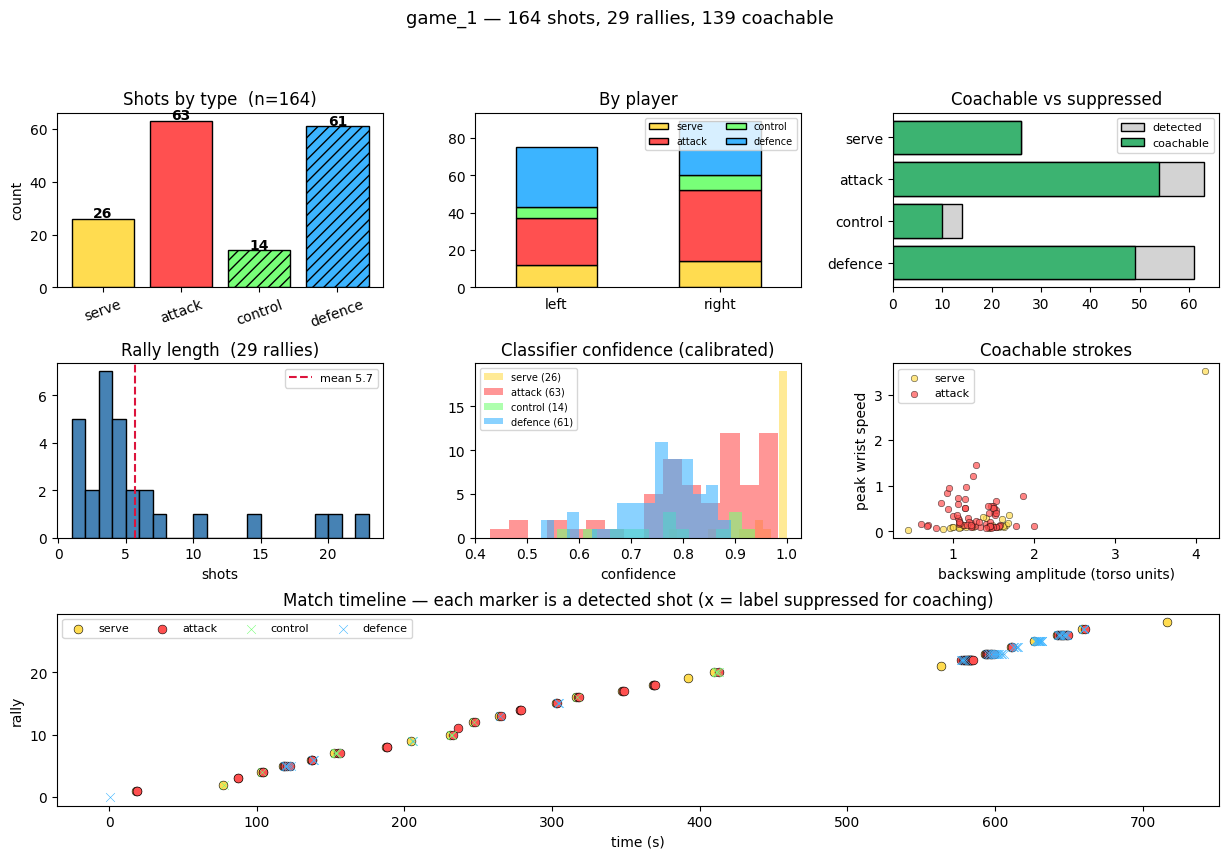


class       count  coachable  mean conf
serve          26         26      0.971
attack         63         54      0.826
control        14         10      0.783
defence        61         49      0.761
TOTAL         164        139

rallies 29, mean 5.7 shots, longest 22


In [3]:
fig = plt.figure(figsize=(15, 9))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1.1], hspace=0.42, wspace=0.28)

# --- shot counts by class ---
ax = fig.add_subplot(gs[0, 0])
cnt = shots.shot_class.value_counts().reindex(CLASSES).fillna(0)
bars = ax.bar(CLASSES, cnt.values,
              color=[np.array(COL[c][::-1])/255 for c in CLASSES], edgecolor="k")
for b, c in zip(bars, CLASSES):
    if c in ("control", "defence"): b.set_hatch("///")
for i, v in enumerate(cnt.values):
    ax.text(i, v+0.5, int(v), ha="center", fontweight="bold")
ax.set_title(f"Shots by type  (n={len(shots)})"); ax.set_ylabel("count")
ax.tick_params(axis="x", rotation=20)

# --- by player ---
ax = fig.add_subplot(gs[0, 1])
pt = pd.crosstab(shots.player, shots.shot_class).reindex(columns=CLASSES, fill_value=0)
pt.plot.bar(ax=ax, stacked=True,
            color=[np.array(COL[c][::-1])/255 for c in CLASSES], edgecolor="k")
ax.set_title("By player"); ax.set_xlabel(""); ax.tick_params(axis="x", rotation=0)
ax.legend(fontsize=7, ncol=2)

# --- coachable ---
ax = fig.add_subplot(gs[0, 2])
co = shots.groupby("shot_class").abstain.agg(["size", lambda s: (~s).sum()])
co.columns = ["total", "coachable"]; co = co.reindex(CLASSES).fillna(0)
ax.barh(CLASSES, co.total, color="lightgrey", edgecolor="k", label="detected")
ax.barh(CLASSES, co.coachable, color="mediumseagreen", edgecolor="k", label="coachable")
ax.set_title("Coachable vs suppressed"); ax.legend(fontsize=8)
ax.invert_yaxis()

# --- rally lengths ---
ax = fig.add_subplot(gs[1, 0])
rl = shots.groupby("rally_id").size()
ax.hist(rl, bins=range(1, int(rl.max())+2), color="steelblue", edgecolor="k")
ax.axvline(rl.mean(), color="crimson", ls="--", label=f"mean {rl.mean():.1f}")
ax.set_title(f"Rally length  ({shots.rally_id.nunique()} rallies)")
ax.set_xlabel("shots"); ax.legend(fontsize=8)

# --- confidence ---
ax = fig.add_subplot(gs[1, 1])
for c in CLASSES:
    s = shots[shots.shot_class == c]
    if len(s): ax.hist(s.class_confidence, bins=15, alpha=.6,
                       label=f"{c} ({len(s)})",
                       color=np.array(COL[c][::-1])/255)
ax.set_title("Classifier confidence (calibrated)"); ax.set_xlabel("confidence")
ax.legend(fontsize=7)

# --- kinematics: the coaching signal ---
ax = fig.add_subplot(gs[1, 2])
for c in ["serve", "attack"]:
    s = shots[shots.shot_class == c]
    if len(s): ax.scatter(s.backswing_amplitude, s.peak_wrist_speed, s=22,
                          alpha=.7, label=c, color=np.array(COL[c][::-1])/255,
                          edgecolor="k", linewidth=.4)
ax.set_xlabel("backswing amplitude (torso units)")
ax.set_ylabel("peak wrist speed")
ax.set_title("Coachable strokes"); ax.legend(fontsize=8)

# --- timeline ---
ax = fig.add_subplot(gs[2, :])
for c in CLASSES:
    s = shots[shots.shot_class == c]
    if not len(s): continue
    ax.scatter(s.timestamp_s, s.rally_id, s=40, label=c,
               color=np.array(COL[c][::-1])/255, edgecolor="k", linewidth=.4,
               marker="x" if c in ("control","defence") else "o")
for r, g in shots.groupby("rally_id"):
    ax.plot([g.timestamp_s.min(), g.timestamp_s.max()], [r, r],
            color="grey", lw=1, alpha=.5, zorder=0)
ax.set_xlabel("time (s)"); ax.set_ylabel("rally")
ax.set_title("Match timeline - each marker is a detected shot "
             "(x = label suppressed for coaching)")
ax.legend(ncol=4, fontsize=8)

plt.suptitle(f"{VIDEO_ID} - {len(shots)} shots, {shots.rally_id.nunique()} rallies, "
             f"{(~shots.abstain).sum()} coachable", fontsize=13, y=0.995)
plt.savefig(BASE/f"outputs/figures/{VIDEO_ID}_dashboard.png", dpi=120,
            bbox_inches="tight")
plt.show()

print(f"\n{'class':<10}{'count':>7}{'coachable':>11}{'mean conf':>11}")
for c in CLASSES:
    s = shots[shots.shot_class == c]
    if not len(s): continue
    print(f"{c:<10}{len(s):>7}{(~s.abstain).sum():>11}{s.class_confidence.mean():>11.3f}")
print(f"{'TOTAL':<10}{len(shots):>7}{(~shots.abstain).sum():>11}")
print(f"\nrallies {shots.rally_id.nunique()}, mean {rl.mean():.1f} shots, "
      f"longest {rl.max()}")

## 3. Annotated video

Every tracker drawn on the footage. Rendering is per-frame at 1080p, so pick a range rather than the whole match - a 30 s clip at 120 fps is 3,600 frames and takes a couple of minutes.

Set `RALLY` to a rally index, or `START_S`/`END_S` for an arbitrary window.

In [5]:
# =============================================================================
# CELL 3 - ANNOTATED VIDEO  (corrected)
#
# Fix: `arr[mask] or [1]` is invalid for numpy - `or` needs a scalar truth
# value and an array with >1 element has none. Replaced with an explicit
# emptiness check. Also guards against an all-zero speed series.
# =============================================================================

RALLY     = int(shots.groupby("rally_id").size().idxmax())   # longest rally
START_S   = None      # set a number to override RALLY
END_S     = None
OUT_SCALE = 0.6       # 1080p -> 648p keeps the file small
PAD_S     = 2.0

import numpy as np, cv2, subprocess
from pathlib import Path
from tqdm.auto import tqdm

if START_S is None:
    g = shots[shots.rally_id == RALLY]
    START_S, END_S = g.timestamp_s.min()-PAD_S, g.timestamp_s.max()+PAD_S
    print(f"rally {RALLY}: {len(g)} shots, {START_S:.1f}s - {END_S:.1f}s")

f0, f1 = int(START_S*FPS), int(END_S*FPS)


def torso_scale(kp):
    """Median shoulder-to-hip distance over frames where it is measurable."""
    hip = (kp[:, L_HIP] + kp[:, R_HIP]) / 2
    sho = (kp[:, L_SHO] + kp[:, R_SHO]) / 2
    t = np.linalg.norm(sho - hip, axis=-1)
    t = t[t > 1]                                  # drop undetected frames
    return float(np.median(t)) if t.size else 1.0  # <-- the fix


def wrist_speed_series():
    """Per-frame max wrist speed for each player, torso-normalised.
    This is the signal the contact detector reads."""
    sp = np.zeros((len(FIDX), 2), np.float32)
    for pi in (0, 1):
        kp = KP[:, pi]
        ts = torso_scale(kp)
        for w in (L_WRI, R_WRI):
            v = np.zeros(len(kp), np.float32)
            v[1:] = np.linalg.norm(np.diff(kp[:, w], axis=0), axis=-1)
            v[SC[:, pi, w] < 0.35] = 0            # ignore unreliable keypoints
            sp[:, pi] = np.maximum(sp[:, pi], v/max(ts, 1e-3))
    return sp

WSPD = wrist_speed_series()
print(f"wrist-speed traces: {WSPD.shape}, "
      f"max L {WSPD[:,0].max():.3f} / R {WSPD[:,1].max():.3f}")


def draw_panel(img, frame, counts, rally_now, shot_now):
    ov = img.copy()
    cv2.rectangle(ov, (10, 10), (330, 210), (25, 25, 25), -1)
    cv2.addWeighted(ov, .72, img, .28, 0, img)
    def T(txt, y, col=(255,255,255), sc=.62, th=2):
        cv2.putText(img, txt, (24, y), cv2.FONT_HERSHEY_SIMPLEX, sc, col, th)
    T(f"t {frame/FPS:6.1f}s", 40, (200,200,200), .55, 1)
    T(f"RALLY {rally_now}", 72, (0,255,255), .75)
    T(f"shot  {shot_now}", 98, (200,200,200), .55, 1)
    y = 130
    for c in CLASSES:
        T(f"{c:<8} {counts[c]:>3}", y, COL[c], .58, 2); y += 25
    return img


def draw_trace(img, frame):
    """Wrist-speed traces for both players over the last 3 s."""
    h, w = img.shape[:2]
    ph, pw = 110, w-40
    x0, y0 = 20, h-ph-20
    ov = img.copy(); cv2.rectangle(ov, (x0,y0), (x0+pw,y0+ph), (20,20,20), -1)
    cv2.addWeighted(ov, .72, img, .28, 0, img)

    lo, hi = frame-int(3*FPS), frame
    idx = [F2I.get(f) for f in range(lo, hi)]
    vals = np.array([[WSPD[i,0], WSPD[i,1]] if i is not None else [0.0, 0.0]
                     for i in idx], np.float32)
    if vals.size:
        m = float(vals.max())
        if m < 1e-6: m = 1.0                       # guard: flat series
        for pi, col in ((0,(120,255,120)), (1,(60,180,255))):
            pts = [(int(x0+pw*k/max(len(vals),1)),
                    int(y0+ph-ph*0.9*vals[k,pi]/m)) for k in range(len(vals))]
            if len(pts) > 1:
                cv2.polylines(img, [np.array(pts, np.int32)], False, col, 2)
    for _, s in shots[(shots.frame >= lo) & (shots.frame < hi)].iterrows():
        x = int(x0 + pw*(s.frame-lo)/max(hi-lo, 1))
        cv2.line(img, (x, y0), (x, y0+ph), COL[s.shot_class], 2)
    cv2.putText(img, "wrist speed   green = left   blue = right   "
                     "vertical line = detected contact",
                (x0+8, y0+16), cv2.FONT_HERSHEY_SIMPLEX, .45, (200,200,200), 1)
    return img


def render(f0, f1, out_name):
    src = VIDDIR/f"{VIDEO_ID}.mp4"
    cap = cv2.VideoCapture(str(src))
    cap.set(cv2.CAP_PROP_POS_FRAMES, f0)
    W = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)*OUT_SCALE)
    H = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)*OUT_SCALE)
    tmp = Path("/content/_render.mp4")
    vw = cv2.VideoWriter(str(tmp), cv2.VideoWriter_fourcc(*"mp4v"),
                         FPS/2, (W, H))          # half speed: strokes are a blur at 120fps
    counts = {c: 0 for c in CLASSES}
    flash, rally_now, shot_now = {}, 0, 0

    for f in tqdm(range(f0, f1), desc="render", leave=False):
        ok, img = cap.read()
        if not ok: break

        # --- tracker 1: table box ---
        if TABLE[2] > TABLE[0]:
            cv2.rectangle(img, (int(TABLE[0]), int(TABLE[1])),
                          (int(TABLE[2]), int(TABLE[3])), (255,255,0), 2)

        # --- trackers 2 & 3: player boxes + skeletons ---
        i = F2I.get(f)
        if i is not None:
            for pi, col in ((0,(120,255,120)), (1,(60,180,255))):
                if not DT[i, pi]: continue
                b = BX[i, pi].astype(int)
                cv2.rectangle(img, (b[0],b[1]), (b[2],b[3]), col, 2)
                cv2.putText(img, ["LEFT","RIGHT"][pi], (b[0], max(b[1]-8, 14)),
                            cv2.FONT_HERSHEY_SIMPLEX, .5, col, 2)
                kp, sc = KP[i,pi], SC[i,pi]
                for a, bb in SKEL:
                    if sc[a] > .3 and sc[bb] > .3:
                        cv2.line(img, tuple(kp[a].astype(int)),
                                 tuple(kp[bb].astype(int)), col, 2)
                for j in range(17):
                    if sc[j] > .3:
                        cv2.circle(img, tuple(kp[j].astype(int)), 4,
                                   (0,0,255) if j in (L_WRI, R_WRI) else col, -1)

        # --- shot events ---
        for _, s in shots[shots.frame == f].iterrows():
            counts[s.shot_class] += 1
            rally_now, shot_now = int(s.rally_id), int(s.shot_index)
            flash[f] = s
        for ff in list(flash):
            s = flash[ff]; age = f - ff
            if age > FPS*0.6:
                flash.pop(ff); continue
            i2 = F2I.get(int(s.frame))
            if i2 is None: continue
            pi = 0 if s.player == "left" else 1
            b = BX[i2, pi].astype(int)
            cx, cy = (b[0]+b[2])//2, max(b[1]-30, 40)
            r = int(28 + age*0.8)
            cv2.circle(img, (cx,cy), r, COL[s.shot_class], 3)
            lab = s.shot_class.upper() + ("" if not s.abstain else " (?)")
            for th, cl in ((5,(0,0,0)), (2,COL[s.shot_class])):
                cv2.putText(img, lab, (cx-70, max(cy-r-10, 24)),
                            cv2.FONT_HERSHEY_SIMPLEX, .8, cl, th)

        # --- tracker 4: the detector's input signal ---
        img = draw_trace(img, f)
        img = draw_panel(img, f, counts, rally_now, shot_now)
        vw.write(cv2.resize(img, (W, H)))

    vw.release(); cap.release()
    out = OUTV/out_name
    subprocess.run(["ffmpeg","-y","-loglevel","error","-i",str(tmp),
                    "-c:v","libx264","-pix_fmt","yuv420p", str(out)], check=True)
    tmp.unlink(missing_ok=True)
    return out


out = render(f0, f1, f"{VIDEO_ID}_rally{RALLY}.mp4")
print(f"-> {out}  ({out.stat().st_size/1e6:.1f} MB, "
      f"{(f1-f0)/FPS:.0f}s of footage at half speed)")

rally 23: 22 shots, 591.1s - 608.0s
wrist-speed traces: (50465, 2), max L 7.007 / R 9.842


render:   0%|          | 0/2038 [00:00<?, ?it/s]

-> /content/drive/MyDrive/tt_coach/outputs/videos/game_1_rally23.mp4  (9.6 MB, 17s of footage at half speed)


### Play it

In [6]:
from IPython.display import HTML
from base64 import b64encode
data = b64encode(out.read_bytes()).decode()
HTML(f"""
<video width=900 controls loop>
  <source src="data:video/mp4;base64,{data}" type="video/mp4">
</video>
<p style="font-family:monospace;font-size:12px">
cyan box = table &nbsp;|&nbsp; green = left player &nbsp;|&nbsp; blue = right player
&nbsp;|&nbsp; red dots = wrists &nbsp;|&nbsp; (?) = label suppressed for coaching
</p>""")

Output hidden; open in https://colab.research.google.com to view.

## 4. Shot inspector

One stroke, frame by frame, with its kinematics. This is the view the coaching layer will build on.

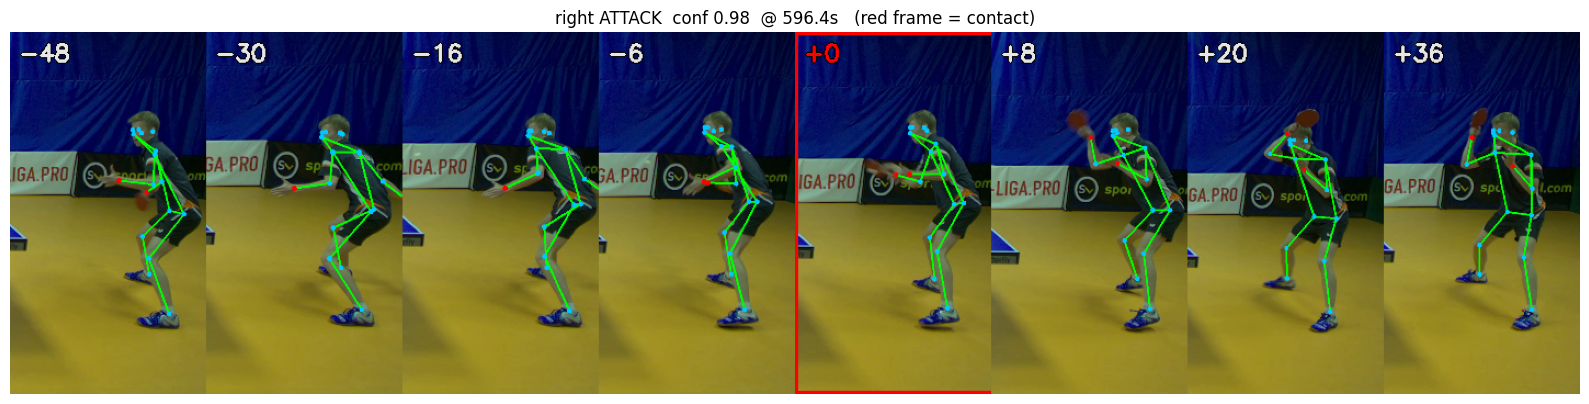

KINEMATICS
  backswing_amplitude    1.501
  peak_wrist_speed       0.507
  time_to_peak           -
  contact_height         -0.417
  elbow_angle            92.290
  elbow_range            130.259
  trunk_lean             24.828
  trunk_rotation         20.959
  table_distance         2.070
  stance_width           0.202
  knee_angle             138.660
  follow_through         1.887
  recovery_time          4.000

  rally 23, shot 6 of 22   coachable: True


In [7]:
SHOT_N = int(shots[(shots.shot_class == "attack") & (~shots.abstain)]
             .class_confidence.idxmax()) if ((shots.shot_class=="attack") &
             (~shots.abstain)).any() else 0
s = shots.iloc[SHOT_N]
offs = [-48, -30, -16, -6, 0, 8, 20, 36]

cap = cv2.VideoCapture(str(VIDDIR/f"{VIDEO_ID}.mp4"))
tiles = []
for o in offs:
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(s.frame)+o)
    ok, img = cap.read()
    if not ok: continue
    i = F2I.get(int(s.frame)+o); pi = 0 if s.player == "left" else 1
    if i is not None and DT[i, pi]:
        kp, sc = KP[i,pi], SC[i,pi]
        for a,b in SKEL:
            if sc[a]>.3 and sc[b]>.3:
                cv2.line(img, tuple(kp[a].astype(int)), tuple(kp[b].astype(int)),
                         (0,255,0), 3)
        for j in range(17):
            if sc[j]>.3:
                cv2.circle(img, tuple(kp[j].astype(int)), 6,
                           (0,0,255) if j in (L_WRI,R_WRI) else (255,200,0), -1)
        b = BX[i,pi].astype(int); pad = 130
        x0,y0 = max(0,b[0]-pad), max(0,b[1]-pad)
        x1,y1 = min(img.shape[1],b[2]+pad), min(img.shape[0],b[3]+pad)
        img = img[y0:y1, x0:x1]
    hh = 330; img = cv2.resize(img, (int(hh*img.shape[1]/img.shape[0]), hh))
    c = (0,0,255) if o == 0 else (230,230,230)
    cv2.putText(img, f"{o:+d}", (8,26), cv2.FONT_HERSHEY_SIMPLEX,.7,(0,0,0),4)
    cv2.putText(img, f"{o:+d}", (8,26), cv2.FONT_HERSHEY_SIMPLEX,.7,c,2)
    if o == 0: cv2.rectangle(img,(0,0),(img.shape[1]-1,img.shape[0]-1),(0,0,255),4)
    tiles.append(img)
cap.release()
w = min(t.shape[1] for t in tiles)
strip = np.hstack([t[:, :w] for t in tiles])
plt.figure(figsize=(16, 4.2)); plt.imshow(strip[:,:,::-1]); plt.axis("off")
plt.title(f"{s.player} {s.shot_class.upper()}  conf {s.class_confidence:.2f}  "
          f"@ {s.timestamp_s:.1f}s   (red frame = contact)")
plt.tight_layout(); plt.show()

print("KINEMATICS")
print("=" * 46)
for k in ["backswing_amplitude","peak_wrist_speed","time_to_peak","contact_height",
          "elbow_angle","elbow_range","trunk_lean","trunk_rotation",
          "table_distance","stance_width","knee_angle","follow_through",
          "recovery_time"]:
    v = s[k]
    print(f"  {k:<22} {v:.3f}" if isinstance(v,(int,float,np.floating))
          and not pd.isna(v) else f"  {k:<22} -")
print(f"\n  rally {int(s.rally_id)}, shot {int(s.shot_index)} of "
      f"{int(s.rally_length)}   coachable: {not s.abstain}")

---
## Outputs

| file | |
|---|---|
| `outputs/figures/{video}_dashboard.png` | six-panel summary |
| `outputs/videos/{video}_rally{n}.mp4` | annotated clip |

To render a different segment, set `START_S` / `END_S` in cell 3 and re-run. To view a different shot, change `SHOT_N` in cell 4.

The kinematics table in cell 4 is exactly what Phase 3 will compare against per-class reference distributions to generate feedback.
